# 2.2 Hide and recover a payload

2.2 Hide and recover a payload: decode decode_me.png's hidden payload,
report PSNR and a difference map against the clean cover, then embed an
equivalent >=256x256-bit payload into both covers (textured vs smooth) at
the same raster positions and show which is the worse hiding place.

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
sys.path.insert(0, str(Path.cwd()))
from starter import embed_lsb, extract_lsb, psnr

ROOT = Path.cwd().parents[1]

In [4]:
def bits_to_uint(bits):
    val = 0
    for b in bits:
        val = (val << 1) | int(b)
    return val

In [5]:
def uint_to_bits(val, n=8):
    return np.array([(val >> i) & 1 for i in range(n - 1, -1, -1)], dtype=np.uint8)

In [6]:
# Part 1: decode decode_me.png

In [7]:
stego = np.asarray(Image.open(ROOT / "images/p2/decode_me.png"))
clean_cover = np.asarray(Image.open(ROOT / "images/p2/cover_textured.png"))

header_bits = extract_lsb(stego, 24, plane=0)
sync = header_bits[0:8]
assert list(sync) == [1, 0, 1, 0, 1, 0, 1, 0], f"sync marker mismatch: {sync}"
height = bits_to_uint(header_bits[8:16])
width = bits_to_uint(header_bits[16:24])
print(f"sync OK, payload {height}x{width}")

sync OK, payload 64x64


In [8]:
n_payload_bits = height * width
all_bits = extract_lsb(stego, 24 + n_payload_bits, plane=0)
payload_bits = all_bits[24:24 + n_payload_bits]
payload_img = (payload_bits.reshape(height, width) * 255).astype(np.uint8)

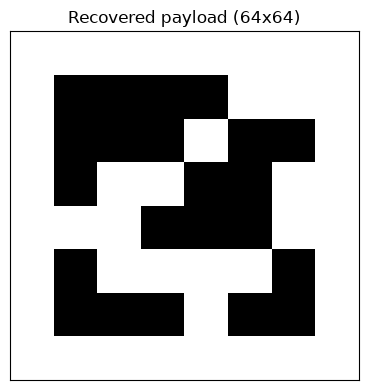

In [9]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(payload_img, cmap="gray", vmin=0, vmax=255)
ax.set_title(f"Recovered payload ({height}x{width})")
ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

In [10]:
stego_psnr = psnr(stego, clean_cover)
print(f"PSNR(stego, clean cover) = {stego_psnr:.2f} dB")

diff_map = (stego != clean_cover)
n_changed = diff_map.sum()
print(f"pixels changed by embedding: {n_changed} / {stego.size} "
      f"({100*n_changed/stego.size:.2f}%)")

PSNR(stego, clean cover) = 75.24 dB
pixels changed by embedding: 2039 / 1048576 (0.19%)


In [11]:
# Header (24 bits) + 64x64 payload (4096 bits) = 4120 bits, embedded at
# consecutive raster positions -> all changes fall in the first
# ceil(4120/1024)=5 rows of a 1024-wide image. A full-frame difference map
# is >99.5% empty by construction and the changed strip is far thinner
# than one displayed pixel row, so it must be shown as its own zoomed
# panel, not relied on to be visible inside a 1024x1024 rendering.
last_changed_row = np.where(diff_map.any(axis=1))[0].max()
crop_rows = last_changed_row + 1
print(f"all changes confined to rows 0..{last_changed_row} "
      f"({crop_rows} of {stego.shape[0]} rows, {100*crop_rows/stego.shape[0]:.2f}%)")

all changes confined to rows 0..4 (5 of 1024 rows, 0.49%)


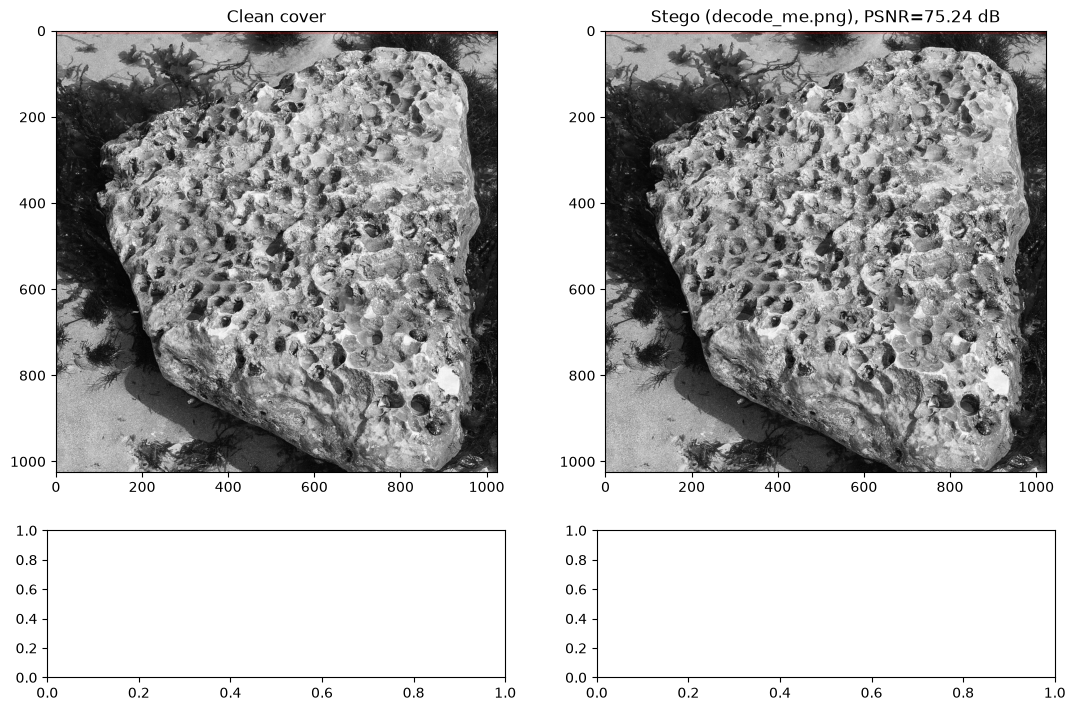

In [12]:
diff_strip = diff_map[:crop_rows, :]

fig, axes = plt.subplots(2, 2, figsize=(13, 8.4),
                          gridspec_kw={"height_ratios": [3, 1]})
axes[0, 0].imshow(clean_cover, cmap="gray")
axes[0, 0].set_title("Clean cover")
axes[0, 1].imshow(stego, cmap="gray")
axes[0, 1].set_title(f"Stego (decode_me.png), PSNR={stego_psnr:.2f} dB")
axes[0, 0].axhspan(-0.5, crop_rows - 0.5, color="red", alpha=0.15)
axes[0, 1].axhspan(-0.5, crop_rows - 0.5, color="red", alpha=0.15)

In [13]:
for ax in axes[0]:
    ax.set_xticks([]); ax.set_yticks([])

gs = axes[1, 0].get_gridspec()
for ax in axes[1]:
    ax.remove()
ax_strip = fig.add_subplot(gs[1, :])
ax_strip.imshow(diff_strip, cmap="gray_r", vmin=0, vmax=1,
                 interpolation="nearest", aspect="auto")
ax_strip.set_title(f"Difference map, rows 0-{last_changed_row} only (red band above) -- "
                    f"{n_changed} pixels changed ({100*n_changed/stego.size:.2f}% of image)",
                    fontsize=10)
ax_strip.set_xlabel("column")
ax_strip.set_yticks(range(crop_rows))
ax_strip.set_ylabel("row")
fig.suptitle(f"All changes confined to the first {crop_rows} rows: header (24 bits) + "
             f"64x64 payload (4096 bits) = 4120 bits embedded at consecutive raster positions",
             fontsize=10, y=0.985)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [14]:
# Part 2: embed a >=256x256-bit payload into both covers, compare hiding quality

In [15]:
cover_textured = np.asarray(Image.open(ROOT / "images/p2/cover_textured.png"))
cover_smooth = np.asarray(Image.open(ROOT / "images/p2/cover_smooth.png"))

PH, PW = 256, 256  # payload size, exactly meets ">= 256x256 bits"
rng = np.random.default_rng(42)
payload = rng.integers(0, 2, size=(PH, PW), dtype=np.uint8)

In [16]:
header = np.concatenate([
    np.array([1, 0, 1, 0, 1, 0, 1, 0], dtype=np.uint8),
    uint_to_bits(PH, 8),
    uint_to_bits(PW, 8),
])
full_bits = np.concatenate([header, payload.flatten()])
print(f"\ntotal embedded bits: {len(full_bits)} (24 header + {PH*PW} payload)")


total embedded bits: 65560 (24 header + 65536 payload)


In [17]:
stego_textured = embed_lsb(cover_textured, full_bits, plane=0)
stego_smooth = embed_lsb(cover_smooth, full_bits, plane=0)

psnr_textured = psnr(stego_textured, cover_textured)
psnr_smooth = psnr(stego_smooth, cover_smooth)
print(f"PSNR textured: {psnr_textured:.2f} dB   PSNR smooth: {psnr_smooth:.2f} dB")

PSNR textured: 63.20 dB   PSNR smooth: 63.20 dB


In [18]:
# PSNR alone is not sufficient (near cover-independent for equal 1-bit
# changes) -- show LOCAL VISIBILITY evidence instead: local variance of the
# change map's effect, i.e. how much the embedding perturbs locally-flat
# regions relative to the cover's own local variability. Compute local
# standard deviation of each cover in a small window, and compare it to the
# magnitude of the embedding-induced change (which is always <=1 LSB) --
# in a smooth region local std is tiny, so a 1-level change is a much
# larger fraction of the local signal (more statistically detectable /
# visible) than in a textured region.
def local_std(img, win=5):
    img = img.astype(np.float64)
    from numpy.lib.stride_tricks import sliding_window_view
    pad = win // 2
    padded = np.pad(img, pad, mode="reflect")
    windows = sliding_window_view(padded, (win, win))
    return windows.std(axis=(-1, -2))

In [19]:
std_textured = local_std(cover_textured)
std_smooth = local_std(cover_smooth)

diff_textured = (stego_textured != cover_textured)
diff_smooth = (stego_smooth != cover_smooth)

In [20]:
# local std AT changed positions only (region where embedding actually altered a pixel)
std_at_changes_textured = std_textured[diff_textured]
std_at_changes_smooth = std_smooth[diff_smooth]

In [21]:
print(f"\nLocal 5x5 std at changed pixels -- textured: mean={std_at_changes_textured.mean():.3f}, "
      f"median={np.median(std_at_changes_textured):.3f}")
print(f"Local 5x5 std at changed pixels -- smooth: mean={std_at_changes_smooth.mean():.3f}, "
      f"median={np.median(std_at_changes_smooth):.3f}")


Local 5x5 std at changed pixels -- textured: mean=16.444, median=11.046
Local 5x5 std at changed pixels -- smooth: mean=3.572, median=3.393


In [22]:
# fraction of changed pixels sitting in near-flat neighbourhoods (std < 1 grey level)
frac_flat_textured = np.mean(std_at_changes_textured < 1.0)
frac_flat_smooth = np.mean(std_at_changes_smooth < 1.0)
print(f"fraction of changed pixels in near-flat (std<1) neighbourhoods -- "
      f"textured: {frac_flat_textured*100:.1f}%  smooth: {frac_flat_smooth*100:.1f}%")

fraction of changed pixels in near-flat (std<1) neighbourhoods -- textured: 0.0%  smooth: 0.2%


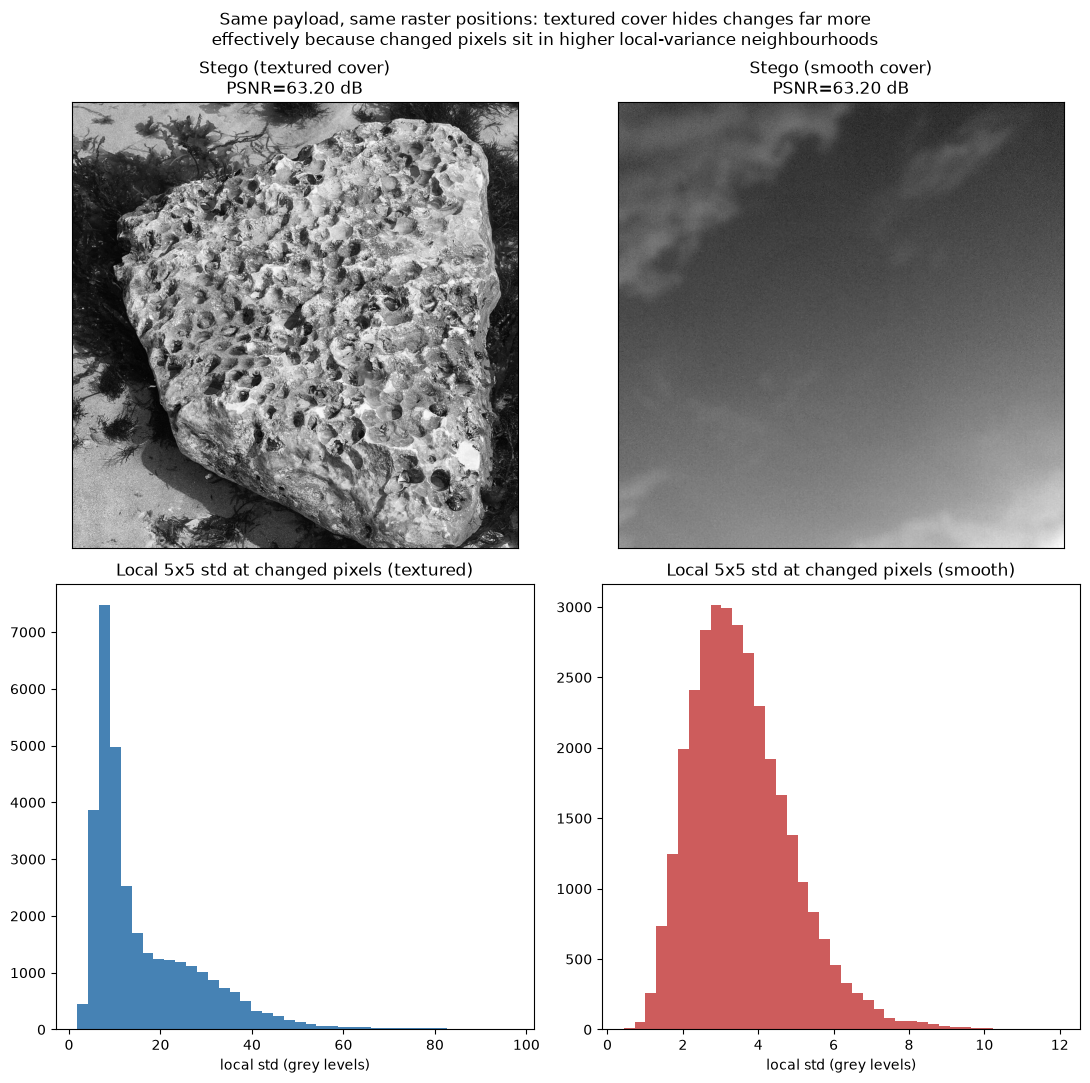

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(11, 11))
axes[0, 0].imshow(stego_textured, cmap="gray")
axes[0, 0].set_title(f"Stego (textured cover)\nPSNR={psnr_textured:.2f} dB")
axes[0, 1].imshow(stego_smooth, cmap="gray")
axes[0, 1].set_title(f"Stego (smooth cover)\nPSNR={psnr_smooth:.2f} dB")
axes[1, 0].hist(std_at_changes_textured, bins=40, color="steelblue")
axes[1, 0].set_title("Local 5x5 std at changed pixels (textured)")
axes[1, 0].set_xlabel("local std (grey levels)")
axes[1, 1].hist(std_at_changes_smooth, bins=40, color="indianred")
axes[1, 1].set_title("Local 5x5 std at changed pixels (smooth)")
axes[1, 1].set_xlabel("local std (grey levels)")
for ax in axes[0]:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Same payload, same raster positions: textured cover hides changes far more\n"
             "effectively because changed pixels sit in higher local-variance neighbourhoods")
fig.tight_layout()
plt.show()